# Importación de librerías

In [1]:
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import filters_and_features as ff
import data_processor as dp
import numpy as np
from sklearn.decomposition import PCA

# Importación de datos

In [2]:
df = dp.lectura(mode=1) # Leyendo 9 primeros individuos
df_val = dp.lectura(mode=2) # Leyendo 10mo individuo

Se crea el dataframe df_block

In [3]:
df_block = dp.create_df_block(df)
df_block_val = dp.create_df_block(df_val)

In [4]:
del df
del df_val

Se limpia y visualiza el contenido

In [5]:
dp.balance(df_block)
dp.balance(df_block_val)
print(df_block['stimulus'].value_counts())
print(df_block_val['stimulus'].value_counts())

stimulus
1     408
0     408
3     408
4     408
6     408
9     408
10    408
11    408
Name: count, dtype: int64
stimulus
1     48
3     48
0     48
4     48
6     48
9     48
10    48
11    48
Name: count, dtype: int64


# Filtro

In [6]:
df_block_filtered = dp.filter(df_block)
df_block_filtered_val = dp.filter(df_block_val)

Procesando: 100%|██████████| 3/3 [00:10<00:00,  3.61s/it]


In [7]:
del df_block
del df_block_val

# Extracción de características

In [8]:
df_block_features = dp.get_carac(df_block_filtered)
df_block_features_val = dp.get_carac(df_block_filtered_val)

Extrayendo Características: 100%|██████████| 384/384 [00:53<00:00,  7.19it/s]


In [9]:
del df_block_filtered
del df_block_filtered_val

In [10]:
df_block_features.describe()

,rms_1,iemg_1,mav_1,wl_1,rms_2,iemg_2,mav_2,wl_2,rms_3,iemg_3,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,...,3264.000000,3.264000e+03,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000
mean,0.000038,0.207866,0.000022,0.093039,0.000069,0.331850,0.000035,0.079801,0.000017,0.096794,...,0.000130,1.432389e-13,266.553717,83.210478,1670.940257,11.702206,118.786182,4.678700,0.128249,5.500000
std,0.000031,0.157799,0.000016,0.057993,0.000142,0.652819,0.000070,0.089711,0.000025,0.108578,...,0.000382,5.698503e-12,46.180899,26.318276,369.146291,6.571713,70.898110,5.258541,0.080378,3.905723
min,0.000004,0.030384,0.000003,0.013674,0.000003,0.018404,0.000002,0.007718,0.000003,0.014321,...,0.000001,4.515274e-19,96.343081,14.000000,634.000000,0.000000,21.799814,1.314194,0.061021,0.000000
25%,0.000023,0.126822,0.000014,0.056737,0.000018,0.098453,0.000011,0.038710,0.000007,0.045890,...,0.000004,3.925759e-18,217.635781,54.000000,1345.000000,6.000000,58.581685,2.054124,0.091250,2.500000
50%,0.000032,0.177794,0.000019,0.080837,0.000025,0.140657,0.000015,0.054638,0.000011,0.074063,...,0.000006,7.908075e-18,296.177897,99.000000,1704.000000,11.000000,102.757733,2.476716,0.096990,5.000000
75%,0.000043,0.244455,0.000025,0.113252,0.000037,0.208326,0.000022,0.081125,0.000018,0.110797,...,0.000230,1.914481e-14,298.720051,102.000000,1988.000000,16.000000,149.063137,6.298326,0.144338,9.250000
max,0.000611,3.198638,0.000315,0.678415,0.000981,5.430075,0.000588,0.875068,0.000682,3.197973,...,0.014789,3.228745e-10,309.396337,114.000000,3311.000000,46.000000,344.141807,127.396453,1.433050,11.000000


In [11]:
df_block_features_val.describe()

,rms_1,iemg_1,mav_1,wl_1,rms_2,iemg_2,mav_2,wl_2,rms_3,iemg_3,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,...,384.000000,3.840000e+02,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.00000
mean,0.000037,0.206315,0.000022,0.095999,0.000052,0.309549,0.000033,0.136305,0.000025,0.142774,...,0.000005,5.130121e-18,297.656060,100.651042,1967.973958,13.838542,150.326238,2.260405,0.093817,5.50000
std,0.000016,0.095180,0.000009,0.049253,0.000022,0.110821,0.000011,0.057534,0.000018,0.083302,...,0.000001,2.153196e-18,2.305193,2.764584,198.156779,4.480882,67.300182,0.413132,0.006647,3.91022
min,0.000011,0.049359,0.000006,0.020072,0.000024,0.102847,0.000013,0.038242,0.000006,0.041323,...,0.000003,2.123225e-18,290.891469,89.000000,1370.000000,1.000000,26.872499,1.277532,0.079615,0.00000
25%,0.000025,0.142228,0.000015,0.063746,0.000040,0.238648,0.000026,0.099584,0.000014,0.088070,...,0.000004,3.368757e-18,296.225341,99.000000,1918.250000,11.000000,86.511068,1.967668,0.089403,2.50000
50%,0.000035,0.188568,0.000020,0.085647,0.000049,0.287768,0.000031,0.122523,0.000020,0.124378,...,0.000005,4.612075e-18,297.846893,101.000000,2000.500000,14.000000,147.474286,2.203885,0.093154,5.00000
75%,0.000045,0.245438,0.000026,0.118305,0.000060,0.364221,0.000038,0.164673,0.000030,0.170898,...,0.000005,6.648275e-18,299.042461,103.000000,2111.000000,17.000000,221.433150,2.481686,0.096681,9.25000
max,0.000103,0.657067,0.000065,0.340550,0.000309,0.910964,0.000097,0.394803,0.000139,0.581695,...,0.000007,1.067287e-17,305.212830,108.000000,2207.000000,30.000000,296.850394,3.861286,0.133558,11.00000


# Normalización

In [12]:
scaler, df_block_normalized = dp.normalize(df_block_features)
df_block_normalized_val = dp.normalize(df_block_features_val, scaler)

In [13]:
del df_block_features
del df_block_features_val

In [14]:
df_block_normalized.describe()

,rms_1,iemg_1,mav_1,wl_1,rms_2,iemg_2,mav_2,wl_2,rms_3,iemg_3,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,...,3.264000e+03,3264.000000,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3264.000000
mean,-5.224579e-17,1.393221e-16,1.306145e-16,6.095342e-17,6.966105e-17,-3.483053e-17,-3.483053e-17,3.483053e-17,-6.966105e-17,-1.741526e-17,...,3.483053e-17,0.000000,2.089832e-16,2.786442e-16,-1.393221e-16,-1.393221e-16,-6.966105e-17,6.966105e-17,2.786442e-16,5.500000
std,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,...,1.000153e+00,1.000153,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,3.905723
min,-1.107915e+00,-1.124904e+00,-1.130989e+00,-1.368734e+00,-4.622551e-01,-4.802168e-01,-4.720304e-01,-8.036282e-01,-5.814169e-01,-7.596946e-01,...,-3.374407e-01,-0.025140,-3.686301e+00,-2.630153e+00,-2.809453e+00,-1.780966e+00,-1.368178e+00,-6.399154e-01,-8.365220e-01,0.000000
25%,-4.845721e-01,-5.136663e-01,-4.996537e-01,-6.260664e-01,-3.627175e-01,-3.575768e-01,-3.545541e-01,-4.581070e-01,-3.982086e-01,-4.689020e-01,...,-3.298014e-01,-0.025139,-1.059430e+00,-1.110063e+00,-8.830922e-01,-8.678223e-01,-8.492994e-01,-4.991837e-01,-4.603818e-01,2.500000
50%,-2.040273e-01,-1.905980e-01,-1.895998e-01,-2.104374e-01,-3.132171e-01,-2.929186e-01,-2.931767e-01,-2.805361e-01,-2.261165e-01,-2.093839e-01,...,-3.252991e-01,-0.025139,6.415795e-01,6.000371e-01,8.957102e-02,-1.068692e-01,-2.261119e-01,-4.188085e-01,-3.889633e-01,5.000000
75%,1.682046e-01,2.319067e-01,2.059234e-01,3.485937e-01,-2.251768e-01,-1.892459e-01,-1.945074e-01,1.476050e-02,3.157274e-02,1.289811e-01,...,2.605689e-01,-0.021780,6.966357e-01,7.140438e-01,8.590316e-01,6.540840e-01,4.271143e-01,3.080464e-01,2.001897e-01,9.250000
max,1.875087e+01,1.895596e+01,1.800114e+01,1.009541e+01,6.434526e+00,7.810747e+00,7.913241e+00,8.866156e+00,2.678468e+01,2.856611e+01,...,3.837902e+01,56.643072,9.278552e-01,1.170071e+00,4.443526e+00,5.219803e+00,3.179071e+00,2.334042e+01,1.623569e+01,11.000000


In [15]:
df_block_normalized_val.describe()

,rms_1,iemg_1,mav_1,wl_1,rms_2,iemg_2,mav_2,wl_2,rms_3,iemg_3,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,...,384.000000,3.840000e+02,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.00000
mean,-0.056359,-0.009829,-0.009100,0.051054,-0.116269,-0.034166,-0.036049,0.629951,0.309077,0.423539,...,-0.328466,-2.513918e-02,0.673593,0.662780,0.804774,0.325130,0.444933,-0.459950,-0.428442,5.50000
std,0.523295,0.603262,0.576734,0.849424,0.153171,0.169783,0.163114,0.641422,0.708114,0.767325,...,0.002643,3.779109e-07,0.049924,0.105060,0.536880,0.681948,0.949398,0.078576,0.082710,3.91022
min,-0.905491,-1.004640,-0.949475,-1.258401,-0.319971,-0.350846,-0.315705,-0.463330,-0.445866,-0.510964,...,-0.333538,-2.513971e-02,0.527090,0.220015,-0.815358,-1.628775,-1.296618,-0.646888,-0.605156,0.00000
25%,-0.424191,-0.416023,-0.394586,-0.505198,-0.201893,-0.142791,-0.141211,0.220553,-0.112337,-0.080359,...,-0.330590,-2.513949e-02,0.642607,0.600037,0.670053,-0.106869,-0.455302,-0.515627,-0.483372,2.50000
50%,-0.120061,-0.122312,-0.116009,-0.127487,-0.141256,-0.067536,-0.061446,0.476290,0.122722,0.254081,...,-0.328762,-2.513927e-02,0.677725,0.676042,0.892899,0.349703,0.404700,-0.470700,-0.436695,5.00000
75%,0.216665,0.238136,0.229418,0.435736,-0.064840,0.049594,0.044172,0.946210,0.516581,0.682593,...,-0.326385,-2.513892e-02,0.703618,0.752046,1.192284,0.806275,1.448032,-0.417863,-0.392805,9.25000
max,2.116234,2.847100,2.649695,4.268576,1.693086,0.887232,0.885432,3.511852,4.898612,4.466597,...,-0.322137,-2.513821e-02,0.837252,0.942057,1.452383,2.784753,2.511936,-0.155469,0.066056,11.00000


# Creación de dataframes de entrenamiento y testeo

In [16]:
y = df_block_normalized.iloc[:, -1]
X = df_block_normalized.iloc[:, :-1]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

In [17]:
y_val = df_block_normalized_val.iloc[:, -1]
X_val = df_block_normalized_val.iloc[:, :-1]

In [18]:
del df_block_normalized
del df_block_normalized_val

In [19]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)

(2284, 183) (2284,)
(384, 183) (384,)


# Entrenamiento y testeo del modelo

Importamos librerías

In [20]:
# Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Rotation forest
from sktime.classification.sklearn import RotationForest
from sktime.datasets import load_unit_test
from sktime.datatypes._panel._convert import from_nested_to_3d_numpy

# Artificial Neural Networks (ANN)
import setuptools.dist
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [21]:
# Visualization libraries

import seaborn as sns

Random forest

In [22]:
rf = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf.fit(X_train, y_train)
y_pred_RanF = rf.predict(X_test)
y_pred_RanF_val = rf.predict(X_val)

Rotation forest

In [23]:
clf = RotationForest(n_estimators=300)
clf.fit(X_train, y_train)
y_pred_RotF = clf.predict(X_test)
y_pred_RotF_val = clf.predict(X_val)

Artificial Neural Networks (ANN)

In [24]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann = le.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_val = le.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


# Resultados

Random forest

Test data

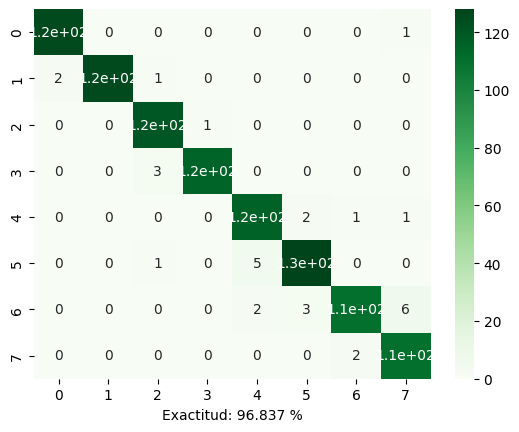

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       126
           1       1.00      0.98      0.99       128
           3       0.96      0.99      0.98       121
           4       0.99      0.97      0.98       118
           6       0.94      0.97      0.95       120
           9       0.96      0.96      0.96       134
          10       0.97      0.91      0.94       121
          11       0.93      0.98      0.96       112

    accuracy                           0.97       980
   macro avg       0.97      0.97      0.97       980
weighted avg       0.97      0.97      0.97       980



In [25]:
sns.heatmap(confusion_matrix(y_pred_RanF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF, y_test))

Validation data

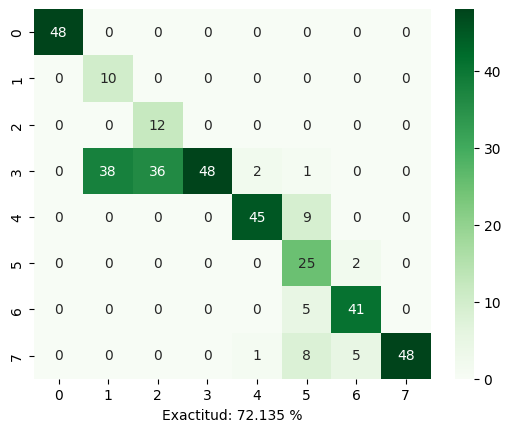

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       0.21      1.00      0.34        10
           3       0.25      1.00      0.40        12
           4       1.00      0.38      0.55       125
           6       0.94      0.83      0.88        54
           9       0.52      0.93      0.67        27
          10       0.85      0.89      0.87        46
          11       1.00      0.77      0.87        62

    accuracy                           0.72       384
   macro avg       0.72      0.85      0.70       384
weighted avg       0.90      0.72      0.74       384



In [26]:
sns.heatmap(confusion_matrix(y_pred_RanF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_val, y_val))

Rotation forest

Test data

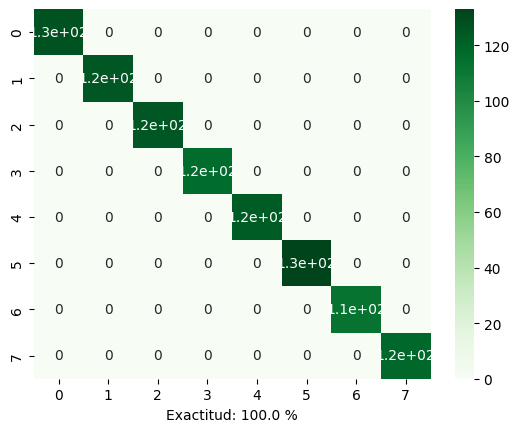

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       127
           1       1.00      1.00      1.00       125
           3       1.00      1.00      1.00       125
           4       1.00      1.00      1.00       116
           6       1.00      1.00      1.00       123
           9       1.00      1.00      1.00       133
          10       1.00      1.00      1.00       113
          11       1.00      1.00      1.00       118

    accuracy                           1.00       980
   macro avg       1.00      1.00      1.00       980
weighted avg       1.00      1.00      1.00       980



In [27]:
sns.heatmap(confusion_matrix(y_pred_RotF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF, y_test))

Validation data

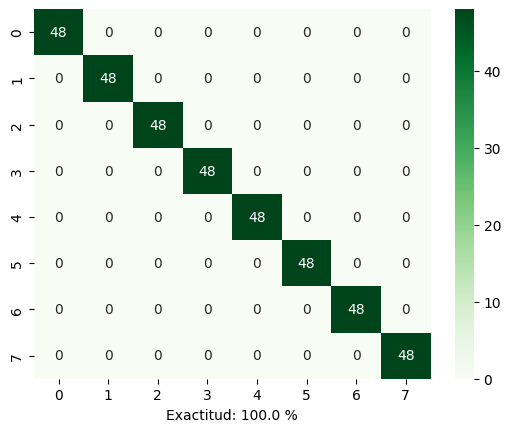

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00        48
           3       1.00      1.00      1.00        48
           4       1.00      1.00      1.00        48
           6       1.00      1.00      1.00        48
           9       1.00      1.00      1.00        48
          10       1.00      1.00      1.00        48
          11       1.00      1.00      1.00        48

    accuracy                           1.00       384
   macro avg       1.00      1.00      1.00       384
weighted avg       1.00      1.00      1.00       384



In [28]:
sns.heatmap(confusion_matrix(y_pred_RotF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_val, y_val))

Artificial Neural Networks (ANN)

Test data

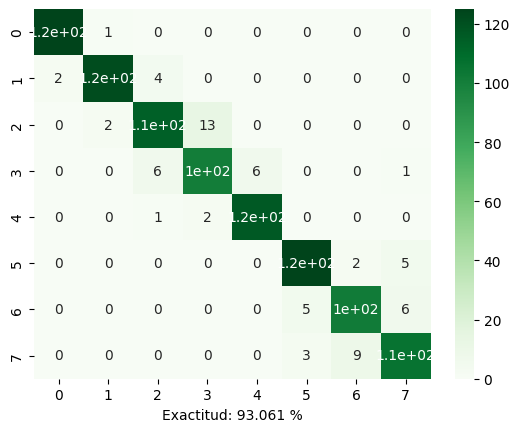

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       126
           1       0.98      0.95      0.96       128
           3       0.91      0.88      0.90       129
           4       0.87      0.89      0.88       114
           6       0.95      0.97      0.96       120
           9       0.94      0.95      0.94       132
          10       0.90      0.90      0.90       113
          11       0.90      0.90      0.90       118

    accuracy                           0.93       980
   macro avg       0.93      0.93      0.93       980
weighted avg       0.93      0.93      0.93       980



In [29]:
sns.heatmap(confusion_matrix(y_pred_ann, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann, y_test))

Validation data

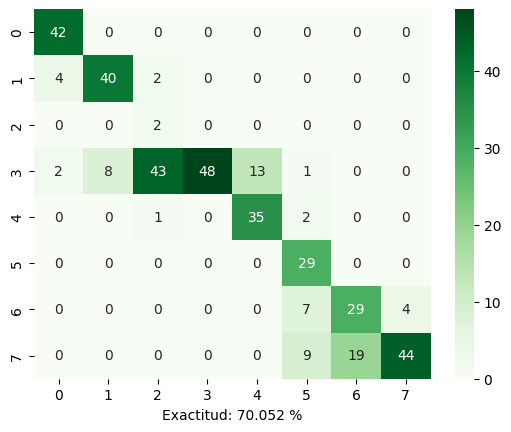

              precision    recall  f1-score   support

           0       0.88      1.00      0.93        42
           1       0.83      0.87      0.85        46
           3       0.04      1.00      0.08         2
           4       1.00      0.42      0.59       115
           6       0.73      0.92      0.81        38
           9       0.60      1.00      0.75        29
          10       0.60      0.72      0.66        40
          11       0.92      0.61      0.73        72

    accuracy                           0.70       384
   macro avg       0.70      0.82      0.68       384
weighted avg       0.85      0.70      0.72       384



In [30]:
sns.heatmap(confusion_matrix(y_pred_ann_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_val, y_val))

# Con PCA

In [31]:
pca = PCA(n_components=80)

X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

X_pca_val = pca.transform(X_val)

In [32]:
print('Sin PCA')
print(X.shape)
print(X_pca.shape)
print('Con PCA')
print(X_val.shape)
print(X_pca_val.shape)

Sin PCA
(3264, 183)
(3264, 26)
Con PCA
(384, 183)
(384, 26)


Random forest

In [33]:
rf_pca = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf_pca.fit(X_train_pca, y_train)
y_pred_RanF_pca = rf_pca.predict(X_test_pca)
y_pred_RanF_pca_val = rf_pca.predict(X_pca_val)

Rotation forest

In [34]:
clf_pca = RotationForest(n_estimators=300)
clf_pca.fit(X_train_pca, y_train)
y_pred_RotF_pca = clf_pca.predict(X_test_pca)
y_pred_RotF_pca_val = clf_pca.predict(X_pca_val)

Artificial Neural Networks (ANN)

In [35]:
le_pca = LabelEncoder()
y_train_enc = le_pca.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le_pca.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_pca, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test_pca)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann_pca = le_pca.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_pca_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_pca_val = le_pca.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step


# Resultados

Random forest

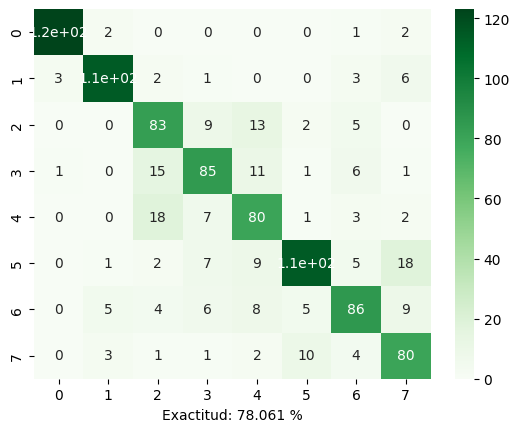

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       128
           1       0.91      0.88      0.90       129
           3       0.66      0.74      0.70       112
           4       0.73      0.71      0.72       120
           6       0.65      0.72      0.68       111
           9       0.86      0.73      0.79       156
          10       0.76      0.70      0.73       123
          11       0.68      0.79      0.73       101

    accuracy                           0.78       980
   macro avg       0.78      0.78      0.78       980
weighted avg       0.79      0.78      0.78       980



In [36]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca, y_test))

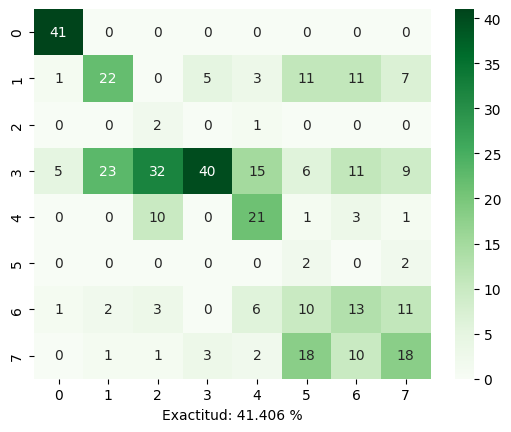

              precision    recall  f1-score   support

           0       0.85      1.00      0.92        41
           1       0.46      0.37      0.41        60
           3       0.04      0.67      0.08         3
           4       0.83      0.28      0.42       141
           6       0.44      0.58      0.50        36
           9       0.04      0.50      0.08         4
          10       0.27      0.28      0.28        46
          11       0.38      0.34      0.36        53

    accuracy                           0.41       384
   macro avg       0.41      0.50      0.38       384
weighted avg       0.59      0.41      0.45       384



In [37]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca_val, y_val))

Rotation forest

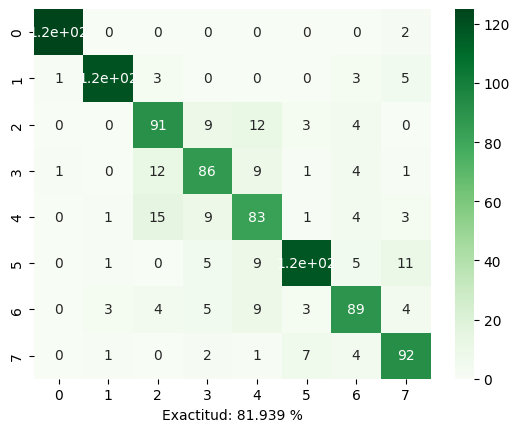

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       127
           1       0.95      0.91      0.93       131
           3       0.73      0.76      0.75       119
           4       0.74      0.75      0.75       114
           6       0.67      0.72      0.69       116
           9       0.89      0.79      0.84       149
          10       0.79      0.76      0.77       117
          11       0.78      0.86      0.82       107

    accuracy                           0.82       980
   macro avg       0.82      0.82      0.82       980
weighted avg       0.82      0.82      0.82       980



In [38]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca, y_test))

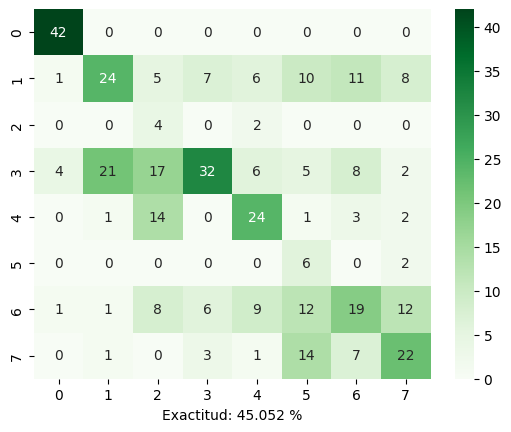

              precision    recall  f1-score   support

           0       0.88      1.00      0.93        42
           1       0.50      0.33      0.40        72
           3       0.08      0.67      0.15         6
           4       0.67      0.34      0.45        95
           6       0.50      0.53      0.52        45
           9       0.12      0.75      0.21         8
          10       0.40      0.28      0.33        68
          11       0.46      0.46      0.46        48

    accuracy                           0.45       384
   macro avg       0.45      0.54      0.43       384
weighted avg       0.54      0.45      0.47       384



In [39]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca_val, y_val))

Artificial Neural Networks (ANN)

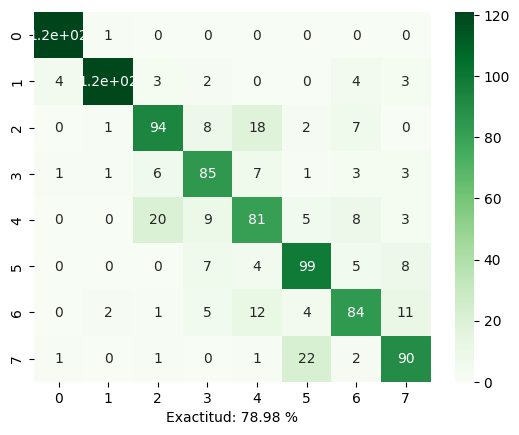

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       122
           1       0.96      0.88      0.92       136
           3       0.75      0.72      0.74       130
           4       0.73      0.79      0.76       107
           6       0.66      0.64      0.65       126
           9       0.74      0.80      0.77       123
          10       0.74      0.71      0.72       119
          11       0.76      0.77      0.77       117

    accuracy                           0.79       980
   macro avg       0.79      0.79      0.79       980
weighted avg       0.79      0.79      0.79       980



In [40]:
sns.heatmap(confusion_matrix(y_pred_ann_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca, y_test))

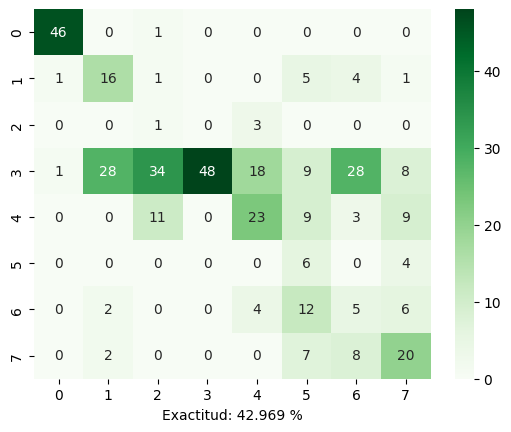

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        47
           1       0.33      0.57      0.42        28
           3       0.02      0.25      0.04         4
           4       1.00      0.28      0.43       174
           6       0.48      0.42      0.45        55
           9       0.12      0.60      0.21        10
          10       0.10      0.17      0.13        29
          11       0.42      0.54      0.47        37

    accuracy                           0.43       384
   macro avg       0.43      0.48      0.39       384
weighted avg       0.71      0.43      0.47       384



In [41]:
sns.heatmap(confusion_matrix(y_pred_ann_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca_val, y_val))

Rpoerte de PCA

In [42]:
X

,rms_1,iemg_1,mav_1,wl_1,rms_2,iemg_2,mav_2,wl_2,rms_3,iemg_3,...,br_13,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14
0,-0.426681,-0.331320,-0.400142,-0.365408,-0.358951,-0.314504,-0.327292,-0.323377,-0.230835,-0.117275,...,-0.295456,0.585574,-0.017138,-1.320928,-1.148066,-0.972501,-1.020013,-0.120350,0.469539,0.317847
1,-0.285953,-0.252028,-0.206585,-0.225042,-0.334574,-0.315670,-0.307806,-0.320084,-0.204851,-0.180124,...,-0.123504,0.885545,-0.010034,-1.390215,-1.034059,-1.246148,-1.324394,-0.500260,0.205085,0.063144
2,-0.639061,-0.717881,-0.635064,-0.810299,-0.392331,-0.409989,-0.394067,-0.611325,-0.286187,-0.409809,...,0.196846,0.379329,-0.017887,-1.667042,-1.224070,-1.622750,-0.563441,-0.801446,0.464527,0.196151
3,-0.435429,-0.284927,-0.352467,-0.317973,-0.352056,-0.318445,-0.330338,-0.338933,-0.267136,-0.177916,...,-0.159961,0.558224,-0.017346,-1.469350,-1.186068,-0.939989,-0.715632,-0.926171,0.213166,0.288540
4,-0.537256,-0.532006,-0.514034,-0.616109,-0.358655,-0.347654,-0.342479,-0.429700,-0.306389,-0.325012,...,0.111456,0.376136,-0.020251,-1.351761,-0.958054,-1.270532,-1.172204,-1.328033,0.205785,0.332952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3259,-0.766623,-0.726070,-0.736271,-0.921244,1.242003,0.697278,0.687393,0.750269,-0.087911,-0.183351,...,-0.563166,-0.326239,-0.025139,0.718730,0.676042,0.986372,-1.020013,1.117564,-0.479838,-0.548008
3260,-0.741918,-0.631614,-0.691582,-0.887577,2.975629,2.872269,2.592277,3.528174,0.629877,0.846606,...,-0.749622,-0.325681,-0.025139,0.682764,0.638039,1.178737,0.806275,-0.620803,-0.474132,-0.384260
3261,-0.905279,-0.871402,-0.872878,-1.159324,2.434899,1.601443,1.639349,1.890458,-0.098690,-0.152523,...,1.086242,-0.325382,-0.025139,0.590526,0.600037,0.631445,0.501893,1.470086,-0.562655,-0.247098
3262,-0.724911,-0.661919,-0.716981,-0.874326,1.616289,1.168366,1.038944,1.519182,0.546546,0.665923,...,-0.641218,-0.323628,-0.025139,0.689125,0.600037,1.094747,0.197512,-0.637348,-0.513542,-0.481147
